In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn
import scipy

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

Python: /Users/khadija/Statapp/ml-uncertainty-quantification-and-sources/.venv/bin/python
NumPy: 2.4.4
Pandas: 2.2.2
scikit-learn: 1.8.0
SciPy: 1.17.1


In [2]:
import sys
import os

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from preprocessor import Preprocessor
from model import LRUQClassifier, LRConfig
from conformal import (
    fit_split_cp_proba,
    coverage_efficiency,
    compute_U,
    test1,
    test2,
    eda_u_distribution,
    eda_u_vs_proba,
    eda_u_by_group
)

print("Imports OK")

Imports OK


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from typing import Optional

In [4]:
preproc = Preprocessor(
    target_column="y",
    drop_columns=["duration"],
    test_size=0.2,
    val_size=0.2,
    random_state=42
)

df = preproc.load_data("../data/bank-full.csv", sep=";")
df = preproc.drop_unwanted_columns(df)
df = preproc.encode_target(df)
splits = preproc.split_data(df)
transformed_data = preproc.fit_transform_splits(splits)

df_test_raw = splits.X_test.copy()
df_test_raw["y"] = splits.y_test.values

X_train = transformed_data["X_train"]
X_val   = transformed_data["X_val"]
X_test  = transformed_data["X_test"]

y_train = transformed_data["y_train"]
y_val   = transformed_data["y_val"]
y_test  = transformed_data["y_test"]

print("Preprocessing complete.")

[encode_target] Classes: {0: 'no', 1: 'yes'}
Proportion y_train : 0.1170
Proportion y_val   : 0.1170
Proportion y_test  : 0.1170
Shapes: (27126, 42), (9042, 42), (9043, 42)
Preprocessing complete.


In [5]:
print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

Shape X_train: (27126, 42)
Shape X_test : (9043, 42)


In [6]:
lr = LRUQClassifier(LRConfig(class_weight={0: 1.0, 1: 8.0}))
lr.fit(X_train, y_train)

In [7]:
alpha = 0.10
cp_model = lr

cp_fit = fit_split_cp_proba(cp_model, X_val, y_val, alpha=alpha)
tau = cp_fit["tau"]

print("\n=== Split CP calibration ===")
print(f"alpha={alpha} | qhat={cp_fit['qhat']:.4f} | tau={tau:.4f}")

uq = compute_U(cp_model, X_test, tau=tau)
pred_sets = uq["pred_sets"]
U = uq["U"]

cp_metrics = coverage_efficiency(pred_sets, y_test)
print("\n=== Split CP evaluation (TEST) ===")
print(f"Target coverage ~ {1-alpha:.2f}")
print(f"Coverage      = {cp_metrics['coverage']:.4f}")
print(f"Avg set size  = {cp_metrics['avg_set_size']:.4f}")


=== Split CP calibration ===
alpha=0.1 | qhat=0.6260 | tau=0.3740

=== Split CP evaluation (TEST) ===
Target coverage ~ 0.90
Coverage      = 0.9007
Avg set size  = 1.4338



=== EDA: distribution de U ===
   count  proportion
1   5120    0.566184
2   3923    0.433816


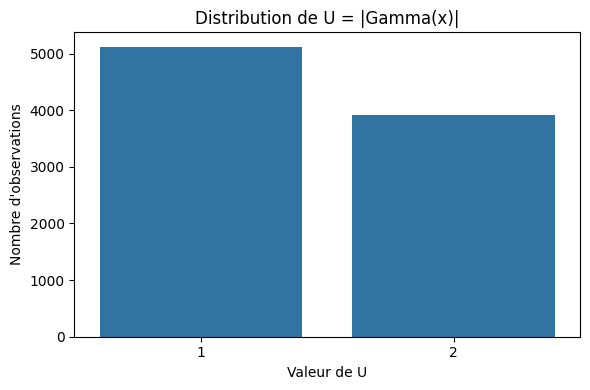


=== EDA: U vs probabilité prédite ===
                p1       margin
count  9043.000000  9043.000000
mean      0.426966     0.169899
std       0.193985     0.118726
min       0.040645     0.000010
25%       0.282126     0.068485
50%       0.406621     0.149989
75%       0.530581     0.259621
max       0.992227     0.492227


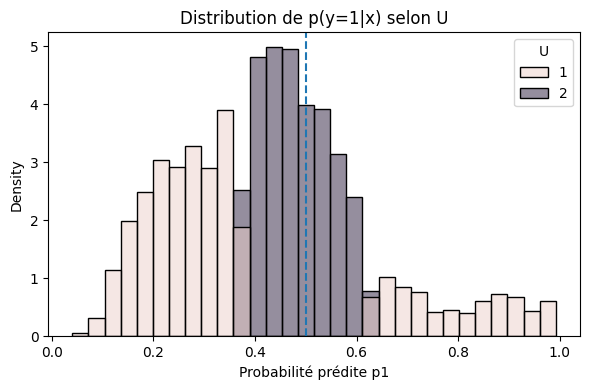


=== Taux d'incertitude par bin de p1 ===
                 uncertainty_rate  count
p1_bin                                  
(0.0397, 0.136]          0.000000    244
(0.136, 0.231]           0.000000   1221
(0.231, 0.326]           0.000000   1480
(0.326, 0.421]           0.493247   1851
(0.421, 0.516]           1.000000   1735
(0.516, 0.612]           1.000000   1177
(0.612, 0.707]           0.191033    513
(0.707, 0.802]           0.000000    264
(0.802, 0.897]           0.000000    281
(0.897, 0.992]           0.000000    277


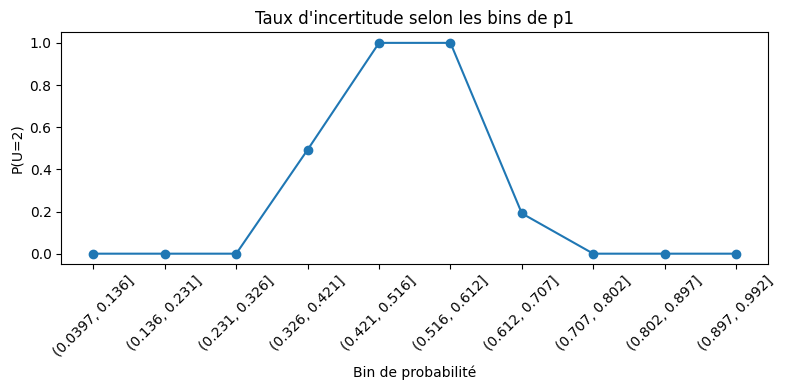


=== EDA: taux d'incertitude par job ===
job
management       0.534669
unemployed       0.508961
entrepreneur     0.508306
technician       0.472858
retired          0.471239
unknown          0.462963
self-employed    0.449405
admin.           0.415534
services         0.397022
blue-collar      0.334911
Name: uncertain, dtype: float64


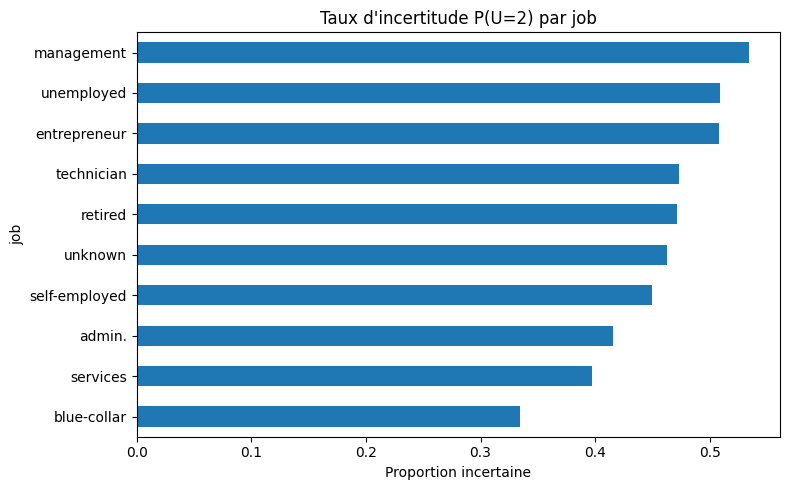


=== EDA: taux d'incertitude par contact ===
contact
cellular     0.566838
telephone    0.392190
unknown      0.149203
Name: uncertain, dtype: float64


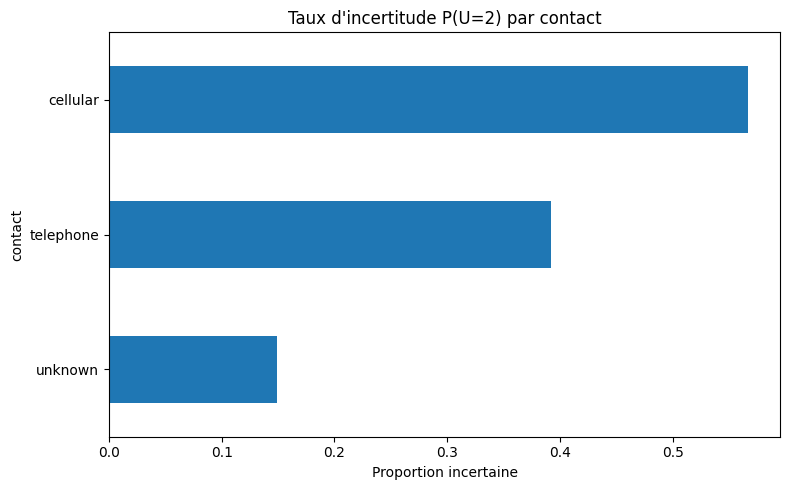


=== EDA: taux d'incertitude par poutcome ===
poutcome
other      0.560563
failure    0.560277
unknown    0.428358
success    0.000000
Name: uncertain, dtype: float64


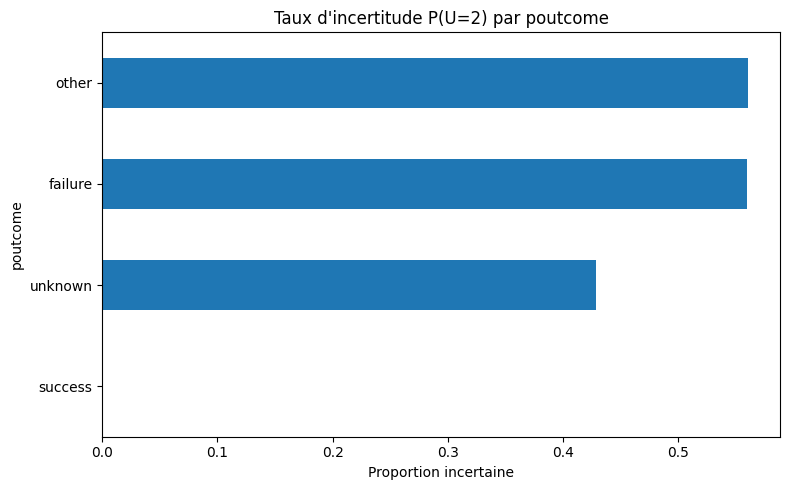


=== EDA: taux d'incertitude par marital ===
marital
divorced    0.517840
single      0.502926
married     0.385265
Name: uncertain, dtype: float64


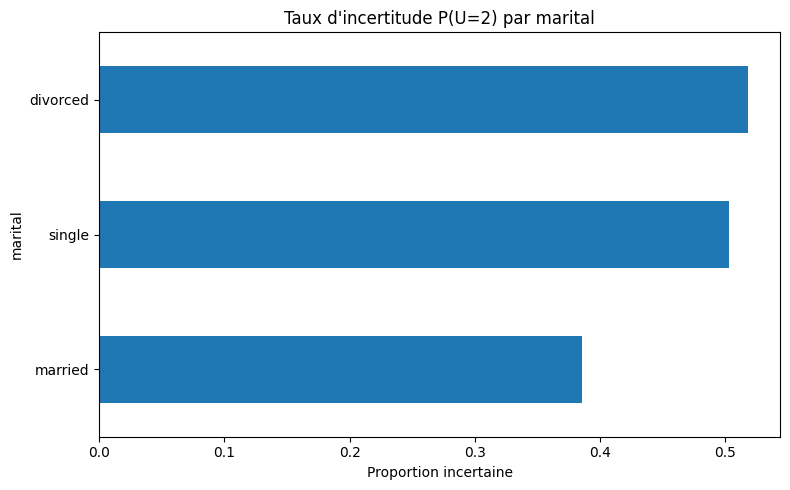


=== EDA: taux d'incertitude par education ===
education
tertiary     0.522719
secondary    0.415428
unknown      0.397333
primary      0.326515
Name: uncertain, dtype: float64


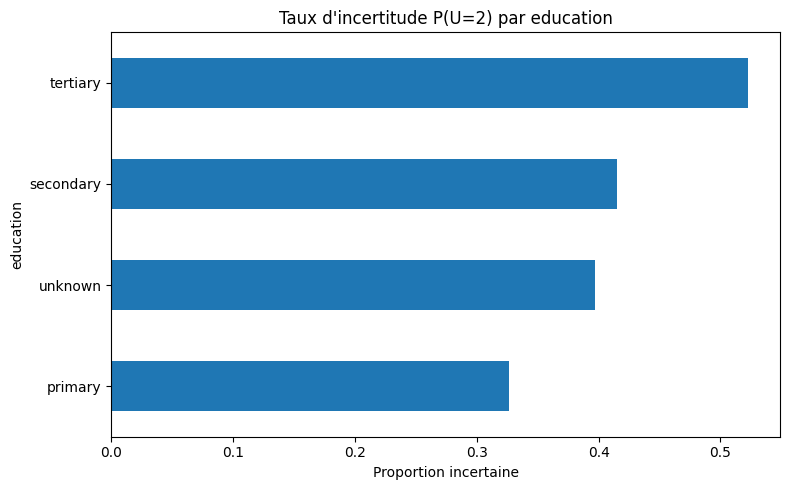

In [8]:
u_summary = eda_u_distribution(U)

u_proba_summary = eda_u_vs_proba(cp_model, X_test, U)

u_group_summary = eda_u_by_group(
    df_test_raw=df_test_raw,
    U=U,
    group_cols=["job", "contact", "poutcome", "marital", "education"]
)


=== TEST H1: Margin vs U ===
Mean margin U=1: 0.2538123051136747
Mean margin U=2: 0.060380672226762265
t-stat: 143.06100404901073
p-value: 0.0

=== Distribution de U ===
U
1    5120
2    3923
Name: count, dtype: int64

Proportions:
U
1    0.566184
2    0.433816
Name: count, dtype: float64


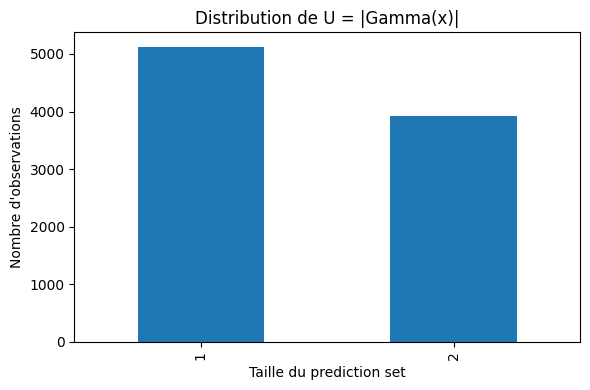


=== Test H1 : margin vs U ===
Mean margin (U=1): 0.2538
Mean margin (U=2): 0.0604
t-stat = 143.0610 | p-value = 0.000e+00


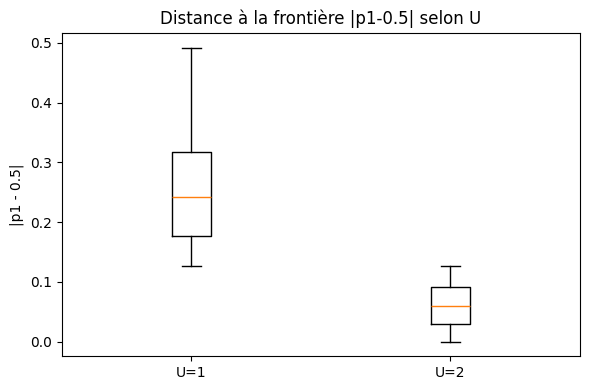


=== Test H2 : U vs erreur ===
Mean U (correct): 1.3631
Mean U (error)  : 1.6280
t-stat = 23.0824 | p-value = 3.508e-111

=== Chi2 : uncertain vs job ===
p-value = 6.946e-51


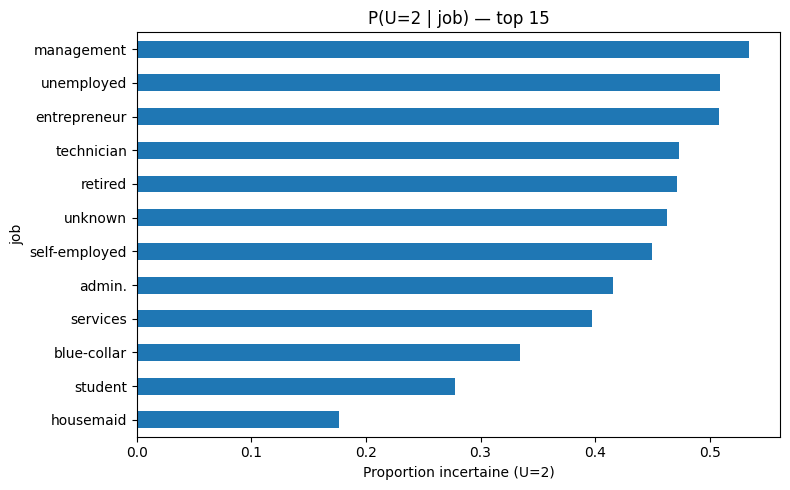


=== Chi2 : uncertain vs contact ===
p-value = 2.620e-281


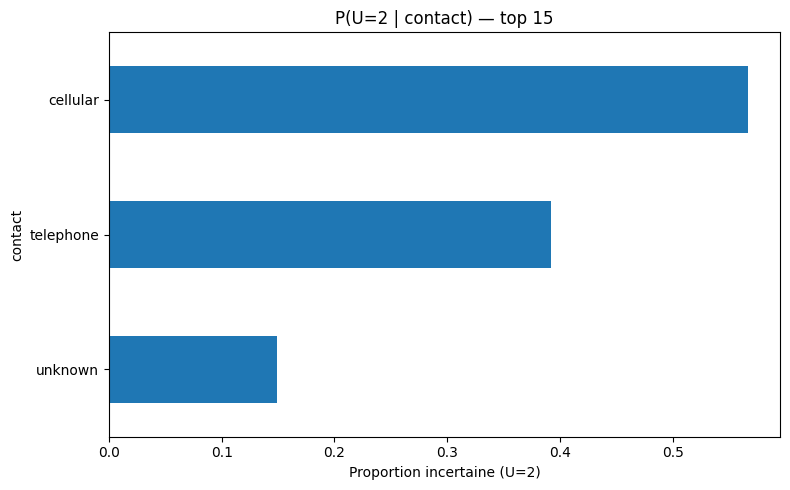


=== Chi2 : uncertain vs poutcome ===
p-value = 5.038e-70


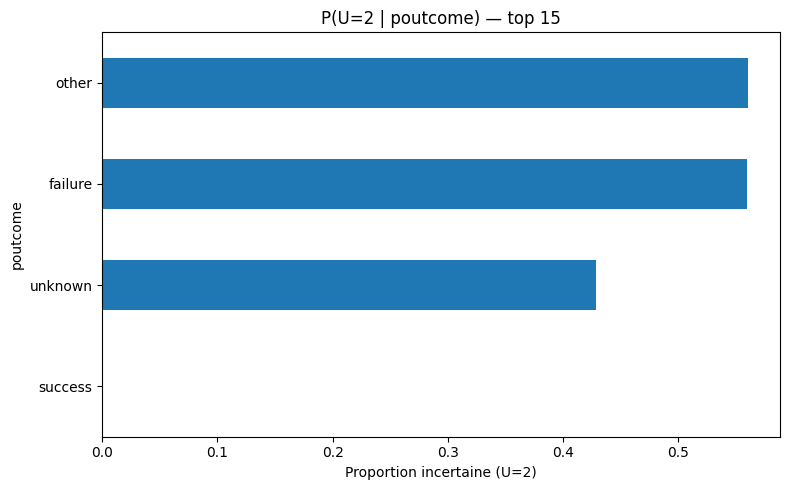


=== Chi2 : uncertain vs marital ===
p-value = 2.303e-29


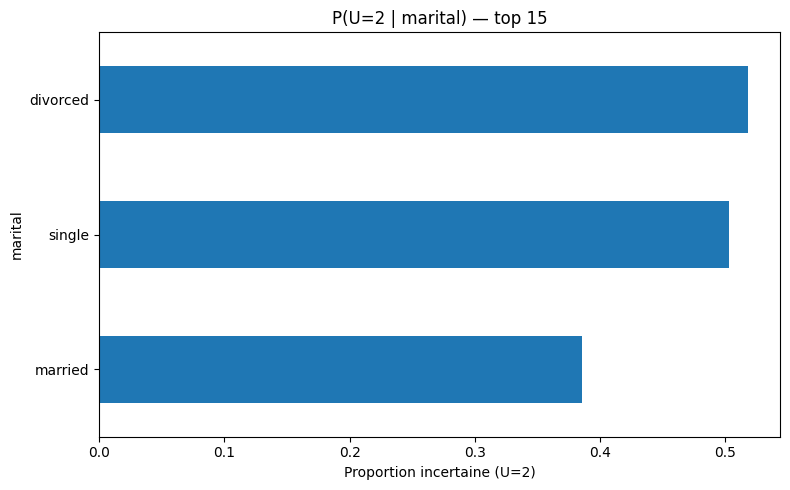


=== Chi2 : uncertain vs education ===
p-value = 6.658e-34


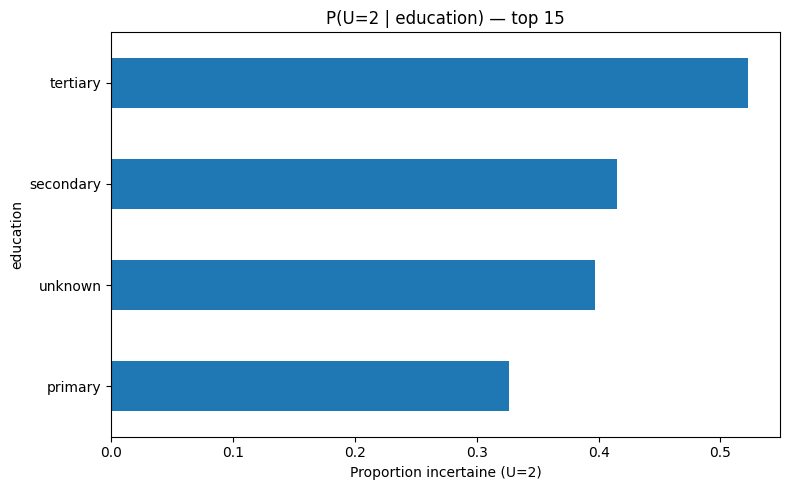


=== P(U=2 | age_bin) ===
age_bin
(0, 30]      0.407687
(30, 40]     0.444538
(40, 50]     0.426418
(50, 60]     0.457667
(60, 100]    0.310502
Name: uncertain, dtype: float64


/Users/khadija/Statapp/ml-uncertainty-quantification-and-sources/src/conformal.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = df.groupby("age_bin")["uncertain"].mean()


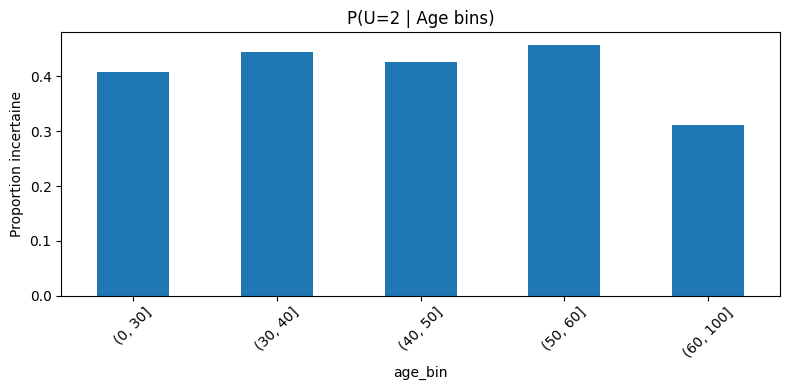

In [9]:
test1(cp_model, X_test, U)

p1_test = cp_model.predict_proba(X_test)[:, 1]

results_tests = test2(
    df_test_raw=df_test_raw,
    U=U,
    p1=p1_test,
    y_true=y_test,
    group_cols=["job", "contact", "poutcome", "marital", "education"]
)

In [11]:
!pip install shap


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from xgboost import XGBClassifier
print("XGBoost OK")

XGBoost OK


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score
)

/Users/khadija/Statapp/ml-uncertainty-quantification-and-sources/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# =========================
# 1. Construire la cible U pour la modélisation
# =========================

# U sur TRAIN
uq_train = compute_U(cp_model, X_train, tau=tau)
U_train = uq_train["U"]

# U sur TEST
uq_test = compute_U(cp_model, X_test, tau=tau)
U_test = uq_test["U"]

# Binarisation : 1 si incertain (prediction set de taille 2), 0 sinon
y_u_train = (U_train == 2).astype(int)
y_u_test  = (U_test == 2).astype(int)

print("=== Distribution de la cible d'incertitude ===")
print("Train:")
print(pd.Series(y_u_train).value_counts(normalize=True).sort_index())
print("\nTest:")
print(pd.Series(y_u_test).value_counts(normalize=True).sort_index())

=== Distribution de la cible d'incertitude ===
Train:
0    0.56197
1    0.43803
Name: proportion, dtype: float64

Test:
0    0.566184
1    0.433816
Name: proportion, dtype: float64


In [14]:
# =========================
# 2. Construire des DataFrames avec noms de variables
# =========================
transformed_data = preproc.fit_transform_splits(splits)

X_train = transformed_data["X_train"]  # numpy array (27126, 42)
X_val   = transformed_data["X_val"]
X_test  = transformed_data["X_test"]

feature_names = preproc.get_feature_names_out()

X_train_df = pd.DataFrame(X_train, columns=feature_names)  # ✓
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)  # ✓

Proportion y_train : 0.1170
Proportion y_val   : 0.1170
Proportion y_test  : 0.1170
Shapes: (27126, 42), (9042, 42), (9043, 42)


In [15]:
# =========================
# 3. Modéliser U avec XGBoost
# =========================

# poids de classe pour compenser un éventuel déséquilibre
n_pos = (y_u_train == 1).sum()
n_neg = (y_u_train == 0).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

xgb_u = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=3,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_u.fit(X_train_df, y_u_train)

# prédictions
y_u_pred = xgb_u.predict(X_test_df)
y_u_pred_proba = xgb_u.predict_proba(X_test_df)[:, 1]

=== Performance du XGBoost pour prédire U ===
Accuracy           : 0.8662
Balanced accuracy  : 0.8758
ROC-AUC            : 0.9460

=== Classification report ===
              precision    recall  f1-score   support

           0     0.9528    0.8035    0.8718      5120
           1     0.7871    0.9480    0.8601      3923

    accuracy                         0.8662      9043
   macro avg     0.8699    0.8758    0.8659      9043
weighted avg     0.8809    0.8662    0.8667      9043



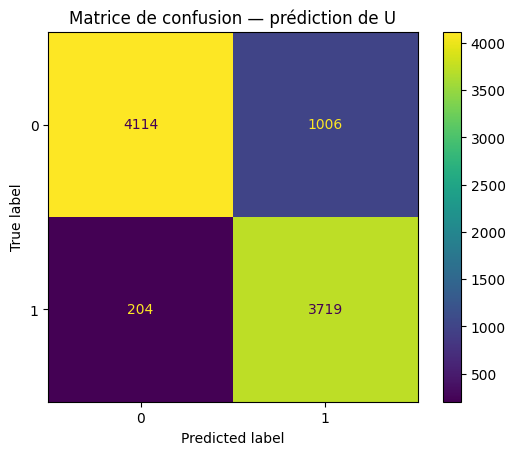

In [16]:
# =========================
# 4. Évaluation du modèle qui prédit U
# =========================

acc = accuracy_score(y_u_test, y_u_pred)
bacc = balanced_accuracy_score(y_u_test, y_u_pred)
auc = roc_auc_score(y_u_test, y_u_pred_proba)

print("=== Performance du XGBoost pour prédire U ===")
print(f"Accuracy           : {acc:.4f}")
print(f"Balanced accuracy  : {bacc:.4f}")
print(f"ROC-AUC            : {auc:.4f}\n")

print("=== Classification report ===")
print(classification_report(y_u_test, y_u_pred, digits=4))

cm = confusion_matrix(y_u_test, y_u_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matrice de confusion — prédiction de U")
plt.show()

In [17]:
# =========================
# 5. SHAP values
# =========================

# Explainer générique SHAP
explainer = shap.Explainer(xgb_u, X_train_df)

# Valeurs de Shapley sur le test set
shap_values = explainer(X_test_df)

print("SHAP values calculées.")
print("Shape :", shap_values.values.shape)

 98%|===================| 8827/9043 [00:24<00:00]        

SHAP values calculées.
Shape : (9043, 42)


=== Top 20 features selon |SHAP| moyen ===


,feature,mean_abs_shap
24,cat_nom__contact_unknown,1.113862
40,cat_bin__housing_yes,0.505510
3,num__campaign,0.404774
1,num__balance,0.376543
18,cat_nom__marital_married,0.346296
37,cat_nom__poutcome_success,0.257834
41,cat_bin__loan_yes,0.180387
2,num__day,0.169164
9,cat_nom__job_housemaid,0.129783
21,cat_nom__education_tertiary,0.121704


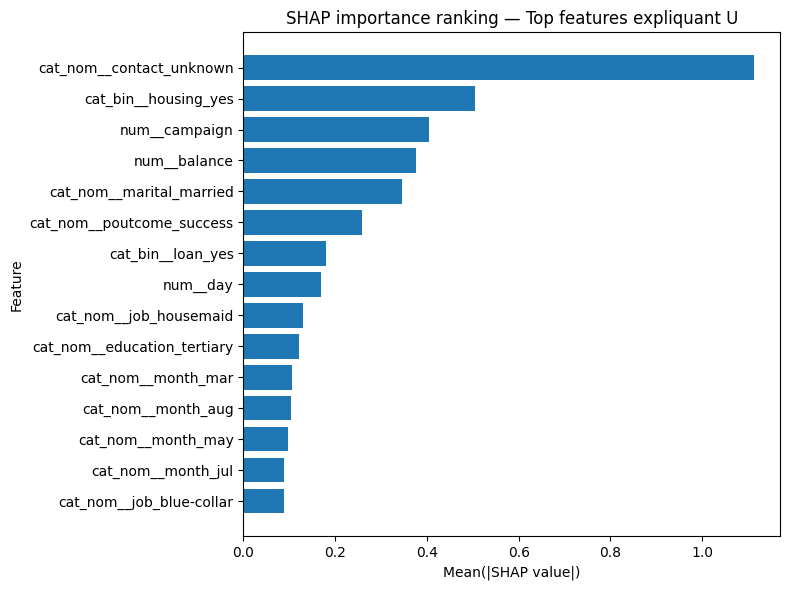

In [18]:
# =========================
# 6. SHAP importance ranking
# =========================

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X_test_df.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print("=== Top 20 features selon |SHAP| moyen ===")
display(shap_importance.head(20))

plt.figure(figsize=(8, 6))
top_k = 15
top_imp = shap_importance.head(top_k).sort_values("mean_abs_shap")
plt.barh(top_imp["feature"], top_imp["mean_abs_shap"])
plt.xlabel("Mean(|SHAP value|)")
plt.ylabel("Feature")
plt.title("SHAP importance ranking — Top features expliquant U")
plt.tight_layout()
plt.show()

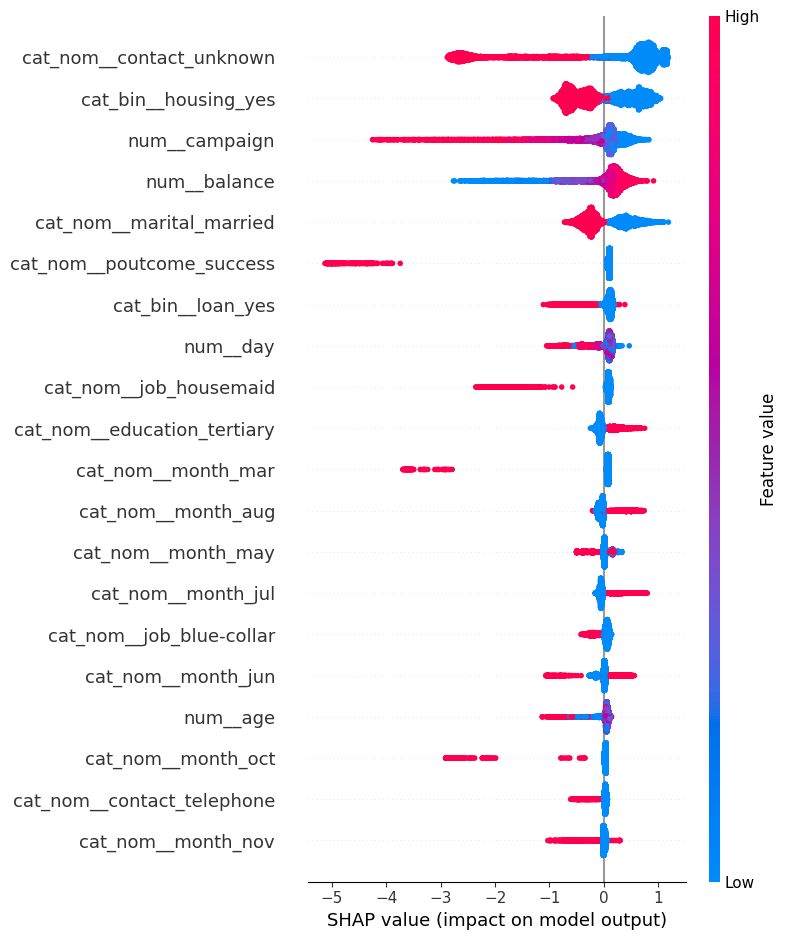

In [19]:
# =========================
# 7. SHAP summary plot (beeswarm)
# =========================

shap.summary_plot(shap_values, X_test_df, max_display=20)

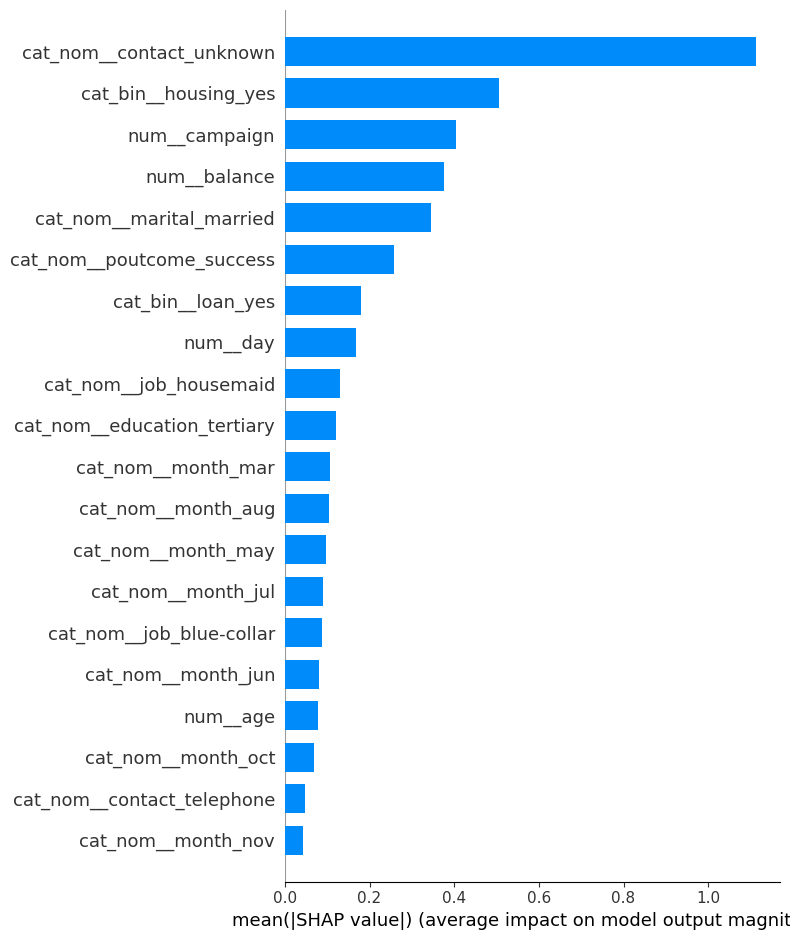

In [20]:
# =========================
# 8. SHAP summary plot (bar)
# =========================
plt.figure(figsize=(19, 8)) # Largeur=10, Hauteur=8
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=20)

Top features : ['cat_nom__contact_unknown', 'cat_bin__housing_yes', 'num__campaign', 'num__balance', 'cat_nom__marital_married']


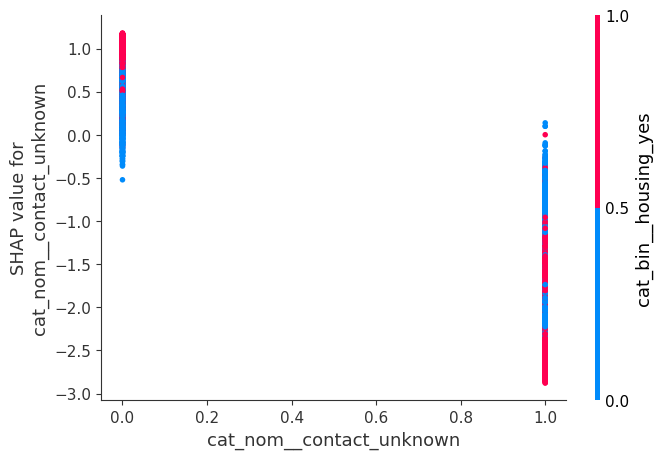

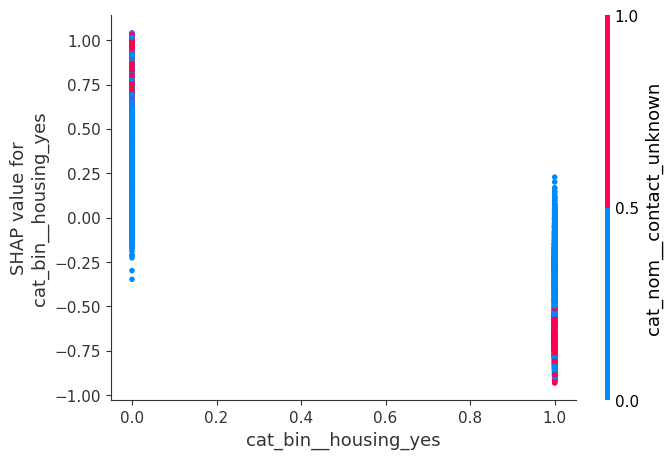

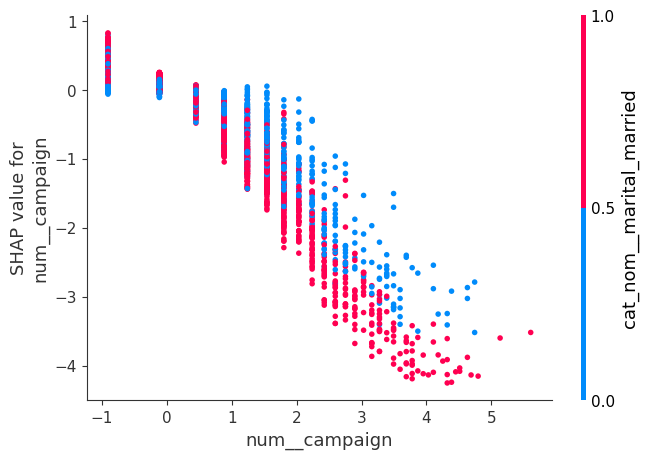

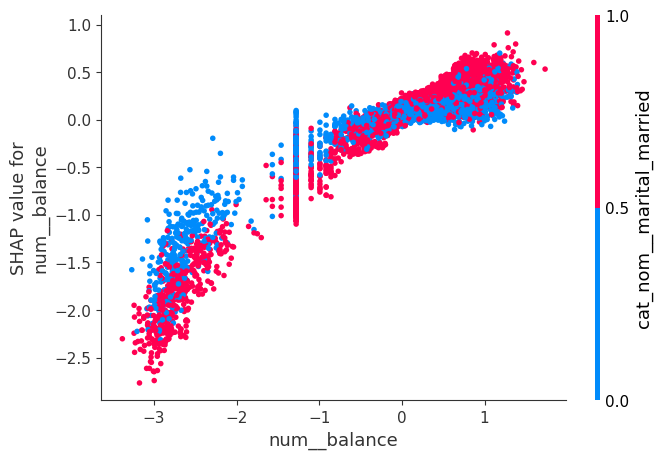

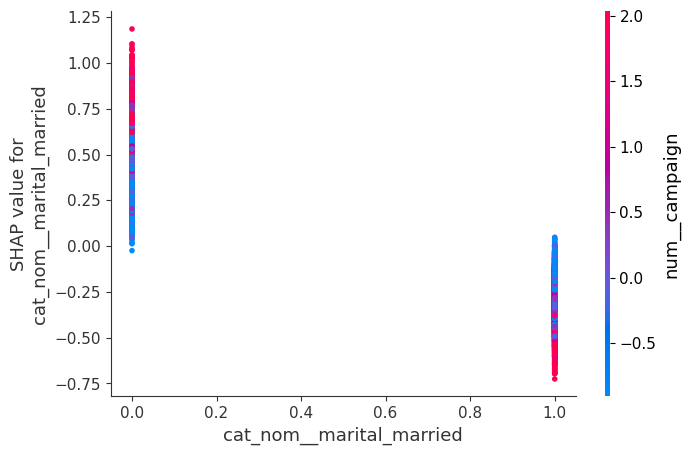

In [21]:
# =========================
# 9. Dependence plots pour les top features
# =========================

top_features = shap_importance["feature"].head(5).tolist()
print("Top features :", top_features)

for feat in top_features:
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_test_df,
        interaction_index="auto",
        show=True
    )

In [23]:
# =========================
# 11. Observations les plus incertaines selon le modèle explicatif
# =========================

results_u = X_test_df.copy()
results_u["U_true"] = y_u_test
results_u["U_pred"] = y_u_pred
results_u["proba_uncertainty"] = y_u_pred_proba

display(results_u.sort_values("proba_uncertainty", ascending=False).head(10))

,num__age,num__balance,num__day,num__campaign,num__previous,num__pdays_contacted,num__pdays_positive,cat_nom__job_blue-collar,cat_nom__job_entrepreneur,cat_nom__job_housemaid,...,cat_nom__month_sep,cat_nom__poutcome_other,cat_nom__poutcome_success,cat_nom__poutcome_unknown,cat_bin__default_yes,cat_bin__housing_yes,cat_bin__loan_yes,U_true,U_pred,proba_uncertainty
20701,0.386128,0.767275,-0.336477,-0.113228,-0.420744,-0.469008,-0.408618,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.953737
19612,0.386128,0.065074,-1.057345,0.885077,-0.420744,-0.469008,-0.408618,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.949729
41039,-0.554358,1.288756,-0.216332,0.885077,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.946902
21746,0.009933,1.244583,0.384391,0.885077,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.944154
18598,-0.366261,-0.182923,1.826128,0.885077,-0.420744,-0.469008,-0.408618,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.943160
19182,0.950419,0.537019,-1.297635,0.885077,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.942074
20367,-0.084115,0.852367,-0.576766,0.448988,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.941938
20985,0.009933,1.320963,-0.216332,-0.113228,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.941417
20161,-0.460310,-1.281085,-0.576766,-0.113228,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.941279
22473,0.668274,0.812191,0.744826,0.885077,-0.420744,-0.469008,-0.408618,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.941174
